In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

In [2]:
data = pd.read_csv(PROJECT_ROOT / "data/raw/hvac_synthetic_dataset_v3.csv")
data.head()

,building_type,climate_zone,budget_level,area_sqft,floors,occupancy,operating_hours,building_age,outdoor_temp,humidity,insulation,glass_ratio,heat_gain,cooling_load,tonnage,energy_consumption,installation_cost,efficiency_score,recommendation_confidence,recommended_hvac
0,Residential,Humid,Medium,1021.68,1.0,21.0,13.0,NaN,31.07,86.64,Good,Medium,1806.78,929.51,0.12,84.35,7204.38,94.0,87.51,Split AC
1,Residential,Cold,Medium,988.86,1.0,12.0,10.0,28.0,15.69,33.84,Average,Low,795.07,826.98,0.07,24.70,5565.45,100.0,87.51,Split AC
2,Office,Hot,Medium,29336.75,3.0,2325.0,8.0,48.0,35.54,43.33,Average,High,275672.68,239930.77,28.79,9204.61,2169512.90,34.0,73.98,Packaged Unit
3,Residential,Warm,Low,882.07,1.0,12.0,11.0,15.0,28.84,54.53,Poor,Low,1035.04,758.61,0.07,20.88,9550.15,71.0,96.81,Packaged Unit
4,Residential,Warm,Medium,1183.55,1.0,20.0,11.0,31.0,33.16,54.31,Average,Low,1623.12,1996.04,0.23,86.16,46864.46,100.0,87.51,Central Chiller


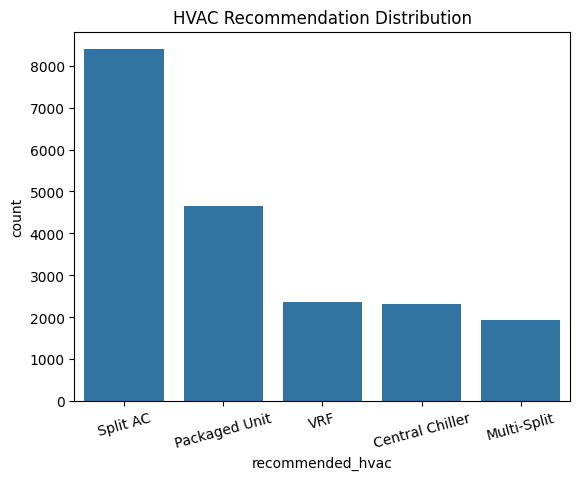

In [3]:
sns.countplot(
    data=data,
    x="recommended_hvac",
    order=data["recommended_hvac"].value_counts().index
)

plt.title("HVAC Recommendation Distribution")
plt.xticks(rotation=15)
plt.show()

In [4]:
print(
    data["recommended_hvac"]
    .value_counts(normalize=True) * 100
)

recommended_hvac
Split AC           42.730515
Packaged Unit      23.662761
VRF                12.007132
Central Chiller    11.777891
Multi-Split         9.821701
Name: proportion, dtype: float64


In [ ]:
numeric_df = data.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
corr_pairs = corr.unstack()

corr_pairs = corr_pairs.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs != 1]

display(corr_pairs.head(20))

cooling_load        tonnage               0.961014
tonnage             cooling_load          0.961014
energy_consumption  tonnage               0.919413
tonnage             energy_consumption    0.919413
heat_gain           cooling_load          0.910370
cooling_load        heat_gain             0.910370
tonnage             installation_cost     0.893562
installation_cost   tonnage               0.893562
tonnage             heat_gain             0.882363
heat_gain           tonnage               0.882363
cooling_load        energy_consumption    0.881999
energy_consumption  cooling_load          0.881999
area_sqft           floors                0.879305
floors              area_sqft             0.879305
cooling_load        installation_cost     0.867381
installation_cost   cooling_load          0.867381
occupancy           area_sqft             0.860859
area_sqft           occupancy             0.860859
installation_cost   energy_consumption    0.825504
energy_consumption  installatio

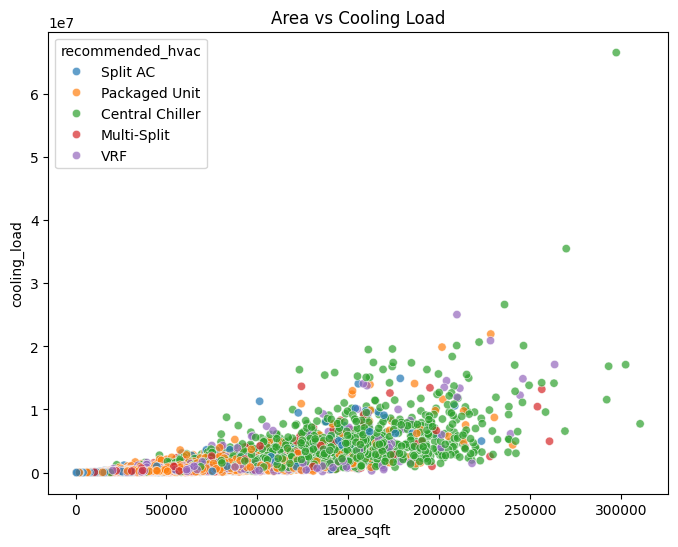

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="area_sqft",
    y="cooling_load",
    hue="recommended_hvac",
    alpha=0.7
)

plt.title("Area vs Cooling Load")
plt.show()